<a href="https://colab.research.google.com/github/Innocent-I/Smart-Irrigation-ML/blob/main/notebooks/03_model_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Smart Irrigation ML — Model Training and Comparison

This notebook trains and evaluates machine learning models for predicting irrigation pump status from environmental sensor data.

## Models

- Logistic Regression
- Decision Tree
- Random Forest

The models will be evaluated using accuracy, precision, recall, F1-score, and confusion matrices.

Their performance will also be compared with the simple soil-moisture threshold baseline developed during preprocessing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Load dataset directly from GitHub

data_url = "https://raw.githubusercontent.com/Innocent-I/Smart-Irrigation-ML/main/data/raw/smart_irrigation_data.csv"

df = pd.read_csv(data_url)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

df.head()

Dataset loaded successfully!
Dataset shape: (3000, 4)


,Soil Moisture,Temperature,Air Humidity,Pump Data
0,683.802906,29.184908,71.789699,0
1,408.571567,33.707205,77.977391,1
2,659.092074,24.760311,60.776282,1
3,842.929764,32.738515,59.323543,0
4,414.199320,25.692744,66.624914,1


In [3]:
# Define features and target

X = df[["Soil Moisture", "Temperature", "Air Humidity"]]
y = df["Pump Data"]

# Same 80/20 stratified split used in preprocessing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

Training set: (2400, 3)
Testing set: (600, 3)


In [4]:
# Standardize features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


In [5]:
# Train Logistic Regression model

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [6]:
# Evaluate Logistic Regression

lr_accuracy = accuracy_score(y_test, logistic_predictions)
lr_precision = precision_score(y_test, logistic_predictions)
lr_recall = recall_score(y_test, logistic_predictions)
lr_f1 = f1_score(y_test, logistic_predictions)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-score :", round(lr_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Logistic Regression Results
---------------------------
Accuracy : 0.9983
Precision: 0.9968
Recall   : 1.0
F1-score : 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       286
           1       1.00      1.00      1.00       314

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [7]:
# Train Decision Tree model

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(X_train, y_train)

dt_predictions = decision_tree_model.predict(X_test)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [8]:
# Evaluate Decision Tree

dt_accuracy = accuracy_score(y_test, dt_predictions)
dt_precision = precision_score(y_test, dt_predictions)
dt_recall = recall_score(y_test, dt_predictions)
dt_f1 = f1_score(y_test, dt_predictions)

print("Decision Tree Results")
print("---------------------")
print("Accuracy :", round(dt_accuracy, 4))
print("Precision:", round(dt_precision, 4))
print("Recall   :", round(dt_recall, 4))
print("F1-score :", round(dt_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, dt_predictions))

Decision Tree Results
---------------------
Accuracy : 0.9983
Precision: 1.0
Recall   : 0.9968
F1-score : 0.9984

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       286
           1       1.00      1.00      1.00       314

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [9]:
# Train Random Forest model

random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [10]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)

print("Random Forest Results")
print("---------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-score :", round(rf_f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Results
---------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       286
           1       1.00      1.00      1.00       314

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [11]:
# Compare model performance

results = pd.DataFrame({
    "Model": [
        "Soil Moisture Threshold",
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.9983,
        lr_accuracy,
        dt_accuracy,
        rf_accuracy
    ],
    "Precision": [
        np.nan,
        lr_precision,
        dt_precision,
        rf_precision
    ],
    "Recall": [
        np.nan,
        lr_recall,
        dt_recall,
        rf_recall
    ],
    "F1 Score": [
        np.nan,
        lr_f1,
        dt_f1,
        rf_f1
    ]
})

display(results.round(4))

,Model,Accuracy,Precision,Recall,F1 Score
0,Soil Moisture Threshold,0.9983,NaN,NaN,NaN
1,Logistic Regression,0.9983,0.9968,1.0000,0.9984
2,Decision Tree,0.9983,1.0000,0.9968,0.9984
3,Random Forest,1.0000,1.0000,1.0000,1.0000


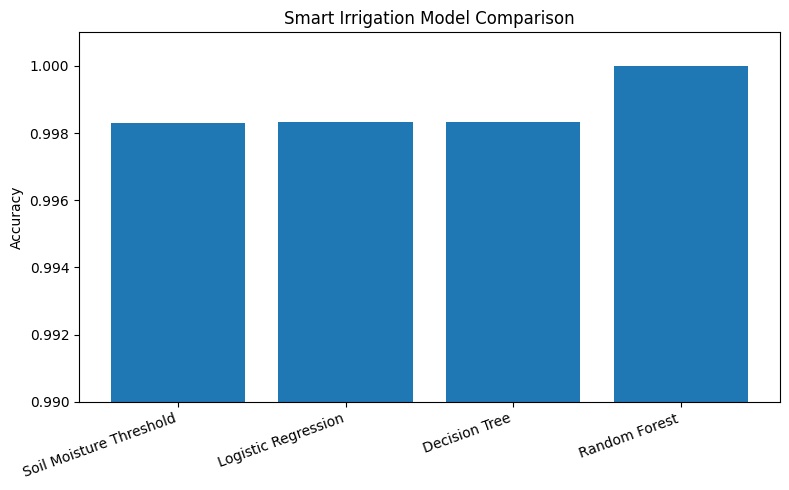

In [12]:
plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Accuracy"])

plt.ylabel("Accuracy")
plt.title("Smart Irrigation Model Comparison")
plt.ylim(0.99, 1.001)
plt.xticks(rotation=20, ha="right")

plt.tight_layout()
plt.show()

Random Forest Feature Importance:


,Feature,Importance
0,Soil Moisture,0.977976
2,Air Humidity,0.011091
1,Temperature,0.010933


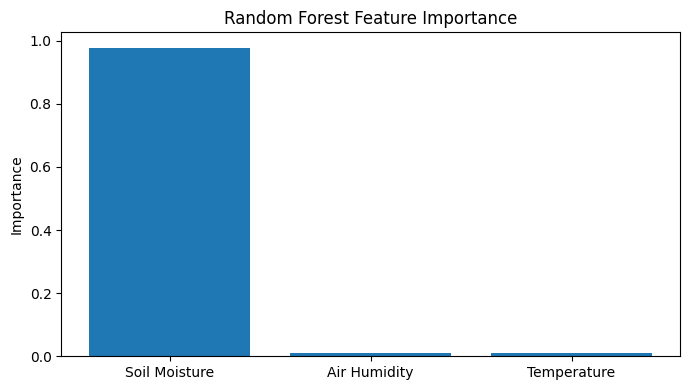

In [13]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("Random Forest Feature Importance:")
display(feature_importance)

plt.figure(figsize=(7, 4))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.ylabel("Importance")
plt.title("Random Forest Feature Importance")
plt.tight_layout()
plt.show()

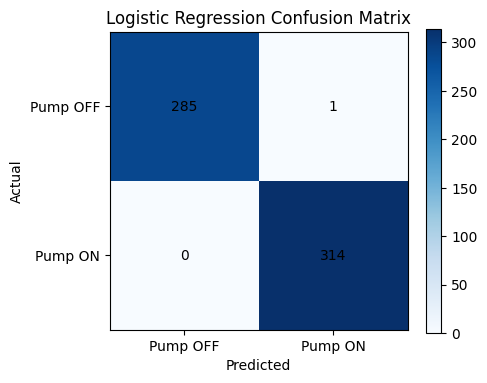

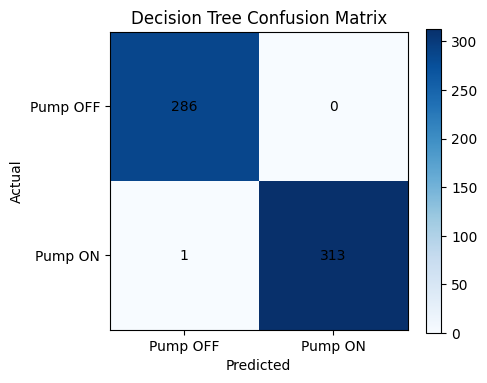

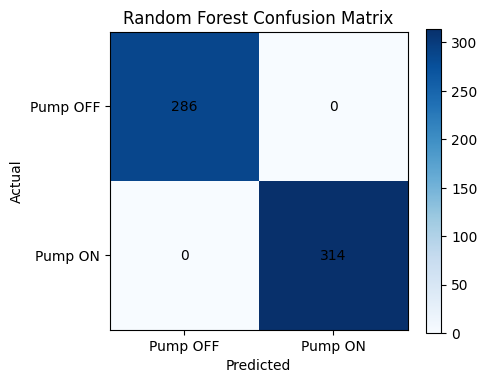

In [14]:
# Confusion matrices for the three ML models

models_predictions = {
    "Logistic Regression": logistic_predictions,
    "Decision Tree": dt_predictions,
    "Random Forest": rf_predictions
}

for model_name, predictions in models_predictions.items():

    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.colorbar()

    plt.xticks([0, 1], ["Pump OFF", "Pump ON"])
    plt.yticks([0, 1], ["Pump OFF", "Pump ON"])

    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(f"{model_name} Confusion Matrix")

    for i in range(2):
        for j in range(2):
            plt.text(
                j, i, cm[i, j],
                ha="center",
                va="center"
            )

    plt.tight_layout()
    plt.show()

## Results and Interpretation

Three machine learning classifiers were evaluated for predicting irrigation pump status: Logistic Regression, Decision Tree, and Random Forest.

The simple soil-moisture threshold baseline achieved approximately 99.83% test accuracy. Logistic Regression and Decision Tree also achieved approximately 99.83% accuracy, while Random Forest achieved 100% accuracy on the test set.

Random Forest feature-importance analysis showed that Soil Moisture accounted for approximately 97.8% of the model's predictive importance, while Air Humidity and Temperature each contributed approximately 1.1%.

These results are consistent with the exploratory analysis, which identified a strong relationship between the raw soil-moisture measurement and pump status.

## Key Finding

Although Random Forest achieved the highest test accuracy, its improvement over the simple soil-moisture threshold was very small. Therefore, the results do not demonstrate that a complex machine learning model is necessary for irrigation decisions in this dataset.

For a simple embedded irrigation controller, a calibrated soil-moisture threshold may provide a more interpretable and computationally efficient solution.

Machine learning may become more valuable when additional information is introduced, such as weather forecasts, rainfall, crop type, soil characteristics, historical irrigation patterns, and remote-sensing observations.

## Limitations

- The dataset contains only three environmental predictor variables.
- Pump status appears to be determined primarily by soil moisture.
- Model performance was evaluated on a single train/test split.
- The results have not yet been validated using independent field data.
- High predictive performance on this dataset should therefore not be interpreted as evidence of equivalent performance under real-world agricultural conditions.

## Future Work

Future versions of this project will investigate:

- Real-time IoT sensor integration
- Weather and rainfall data
- Crop- and soil-specific irrigation requirements
- Prediction of irrigation water quantity
- Remote-sensing and vegetation-index information
- Multimodal models combining ground sensors, weather, and satellite observations